# Week 13 - Lithion Ion Battery Temperature
## Introduction
The temperature of a lithium-ion battery is roughly determined by a balance between the heat that is generated by Joule heating and the heat that is lost into the surrounding environment. The battery temperature can be approximated by the equation $$ T = T_{air} + \frac{I^2R}{h}$$


## Maximum Current

In [6]:
import numpy as np
from scipy.optimize import root

def equation(I,T,T_air,R,h):
    return np.sqrt((h*(T-T_air)) / R) - I

I_guess = 4
T_air = 23
T = 60
R = 3e-4
h = 1.86e-4

sol = root(equation, I_guess, args=(T, T_air, R, h))

I_solution = sol.x[0]
print("Current (I) =", I_solution)

Current (I) = 4.789572005931219


### Result
We found the current to be around 4.8A

## Alternating Current
$$ I(t) = I_0sin(wt) $$

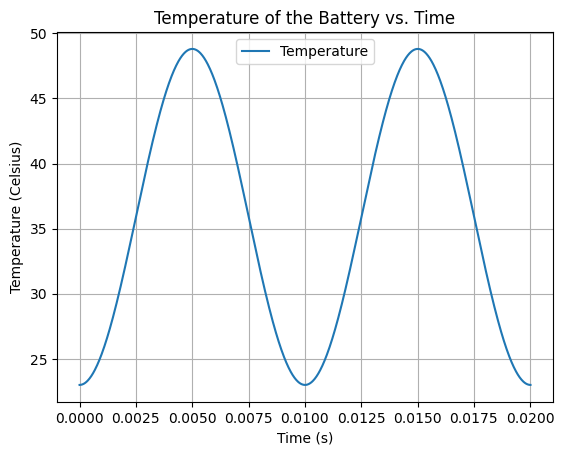

In [11]:
import matplotlib.pyplot as plt

I_0 = 4
w = 314
t = np.linspace(0, 2*np.pi/w, 1000)

I_t = I_0 * np.sin(w * t)

T_t = T_air + (I_t**2 * R) / h

plt.plot(t, T_t, label='Temperature')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (Celsius)')
plt.title('Temperature of the Battery vs. Time')
plt.grid(True)
plt.legend()
plt.show()

## Temperature-dependant Resistance
$$ R = R_0 \text{exp} (\alpha T) $$


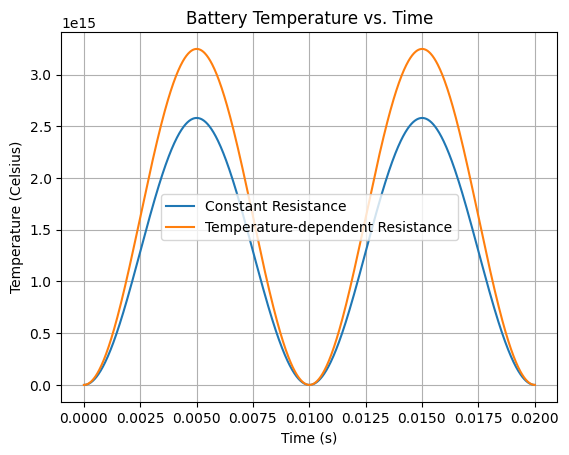

In [14]:
R_0 = 3e10
alpha = 0.01

T_t_constant_R = T_air + (I_t**2 * R_0) / h 

def temperature_temp_dependent(R_0, alpha, T_air, I_t, h):
    R_t = R_0 * np.exp(alpha * T_air)
    return T_air + (I_t**2 * R_t) / h

T_t_temp_dependent = temperature_temp_dependent(R_0, alpha, T_air, I_t, h)

plt.plot(t, T_t_constant_R, label='Constant Resistance')
plt.plot(t, T_t_temp_dependent, label='Temperature-dependent Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (Celsius)')
plt.title('Battery Temperature vs. Time')
plt.grid(True)
plt.legend()
plt.show()

## Result
When α is increased, the temperature-dependent resistance becomes more sensitive to changes in temperature. This means that for the same current, the temperature of the battery will increase more rapidly, leading to higher temperatures over time compared to the case with a lower α value. This effect can be observed in the plot as a steeper increase in temperature for higher values of α.